In [1]:
# 03_time_series_impact.ipynb
# Business Question: Does program group improve faster than control over time?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Data generation
np.random.seed(7)
participants = 120
months = 6
rows = []
for person in range(participants):
    group = np.random.choice(["Control", "Program"])
    baseline = np.random.normal(60, 8)
    for month in range(1, months+1):
        trend = month * (2 if group == "Program" else 0.5)
        productivity = baseline + trend + np.random.normal(0, 4)
        burnout = 70 - productivity + np.random.normal(0, 3)
        rows.append([person, group, month, productivity, burnout])

df3 = pd.DataFrame(rows, columns=["PersonID", "Group", "Month", "Productivity", "Burnout"])
print(df3.head())

   PersonID    Group  Month  Productivity    Burnout
0         0  Program      1     51.900168  17.988531
1         0  Program      2     59.836696   6.882979
2         0  Program      3     56.682709  12.840980
3         0  Program      4     58.983738  11.076455
4         0  Program      5     62.839524   6.017215


In [2]:
# Mixed effects model
model = smf.mixedlm("Productivity ~ Group * Month", df3, groups=df3["PersonID"])
result = model.fit()
print(result.summary())

              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Productivity
No. Observations:    720       Method:               REML        
No. Groups:          120       Scale:                16.0856     
Min. group size:     6         Log-Likelihood:       -2209.1965  
Max. group size:     6         Converged:            Yes         
Mean group size:     6.0                                         
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              61.260    1.138 53.811 0.000 59.029 63.492
Group[T.Program]       -1.429    1.571 -0.909 0.363 -4.508  1.651
Month                   0.477    0.127  3.757 0.000  0.228  0.726
Group[T.Program]:Month  1.451    0.175  8.282 0.000  1.108  1.795
Group Var              59.934    2.224                           



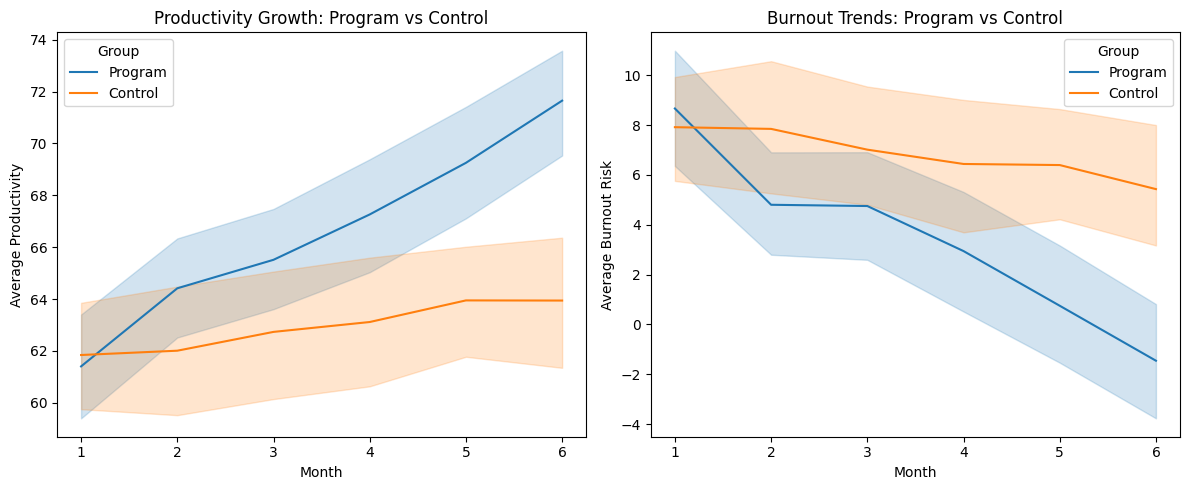

In [3]:
# Time series visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.lineplot(data=df3, x="Month", y="Productivity", hue="Group", estimator='mean')
plt.title("Productivity Growth: Program vs Control")
plt.ylabel("Average Productivity")

plt.subplot(1, 2, 2)
sns.lineplot(data=df3, x="Month", y="Burnout", hue="Group", estimator='mean')
plt.title("Burnout Trends: Program vs Control")
plt.ylabel("Average Burnout Risk")

plt.tight_layout()
plt.savefig('../visuals/time_series_growth.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
df3.to_csv('../data/program_impact_timeseries.csv', index=False)
print("Data saved to program_impact_timeseries.csv")

Data saved to program_impact_timeseries.csv
